In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.signal as signal
import scipy.fft as fft

from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold
#ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfTransformer

from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.manifold import TSNE

from mice_utils import get_split_info,get_labels_subjects, get_sex_labels

import pickle
import shap



Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
strains = ('BXD87', 'DBA2', 'C57B6')
tscs = ('Het', 'WT')
sources = ('Jax_Lab')
types = [strain+tsc for strain in strains for tsc in tscs ]
n_types = len(types)


#mice_df = pd.read_pickle('meta-data/Jax_mice_with_splits_df.pickle')
mice_df = pd.read_pickle('meta-data/all_mice_with_splits_df.pickle')

nfolds,nsplits = get_split_info(mice_df)
print(nsplits,nfolds)


5 2


In [17]:
# Parameters for the segments used for testing
n_seg = 480 # Number of segements per class 
#n_seg = 2880
# Parameters for the dictionary 
window_length = 256*2 # 2s
n_centroids = 200
centroid_len = 256
#n_multiplier = 10
#n_windows = int(n_centroids*20*n_multiplier) 
n_windows = 100000
#n_windows = 40000
str_si = 'sv_sph_svd'
#str_si = 'sv'

#pool_str = 'pooled'
pool_str = ''
use_spectral = False
#use_spectral = True

if use_spectral:
    dict_param_string = 'spectral_'+str(n_windows)+'_'+str(window_length)+'_'+str(n_centroids)
else:
    dict_param_string = str(n_windows)+'_'+str(window_length)+'_'+str(n_centroids)+'_'+str(centroid_len)+'_'+str_si

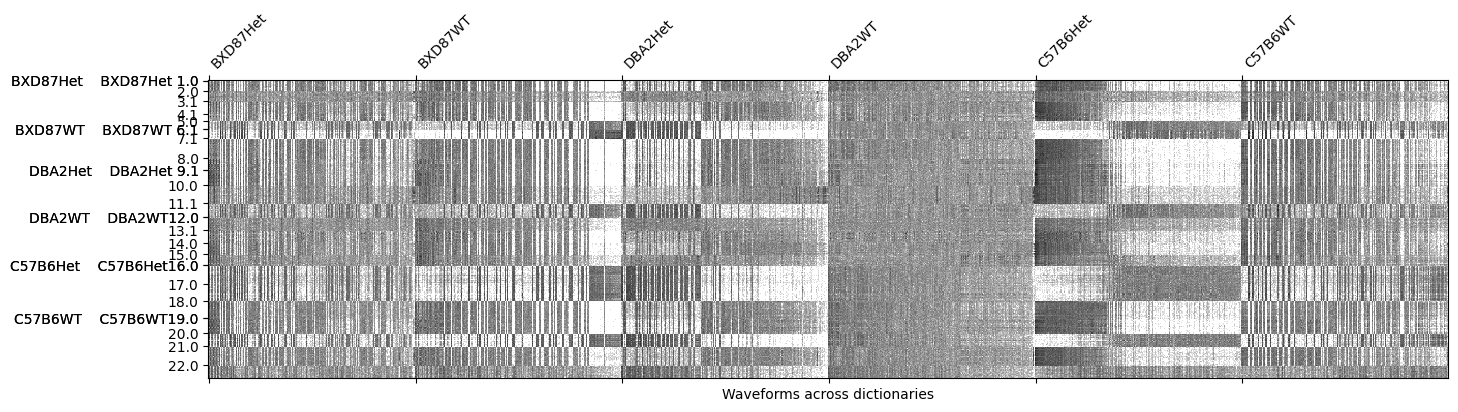

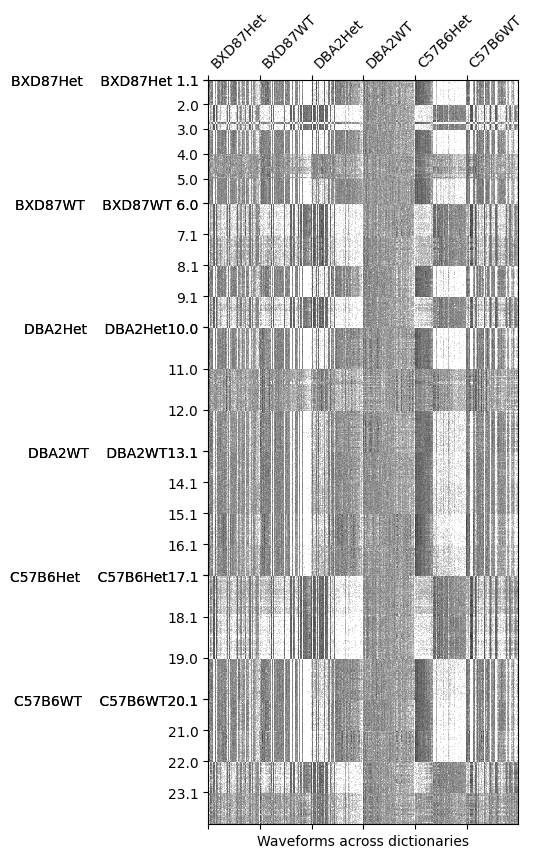

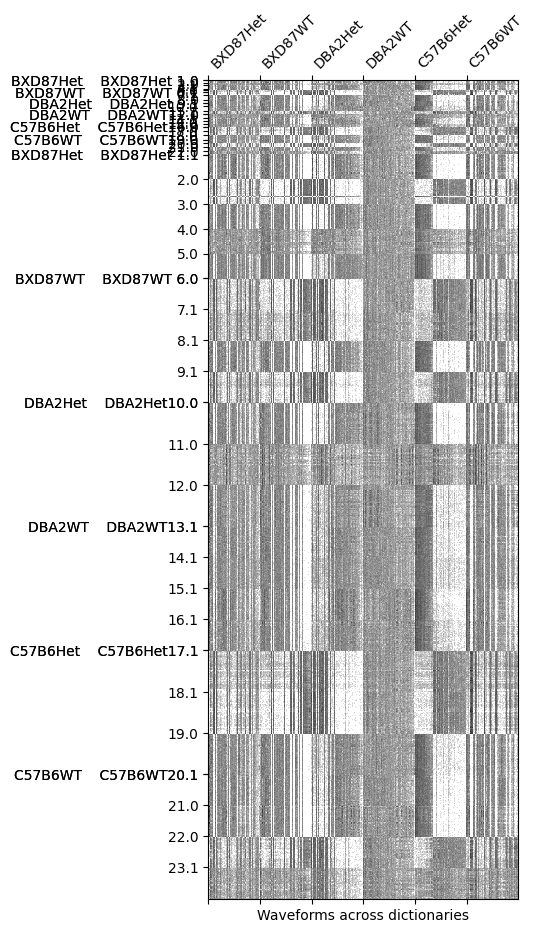

In [18]:
for split in range(1):#range(nsplits):
    for test_fold in range(1):#range(nfolds):
        segment_param_string = str(n_seg)+'_'+str(split)+str(test_fold)+dict_param_string        
        segment_info_train = pickle.load(open( "data/hpc_segment_info_valid_"+segment_param_string+".pickle", "rb" ) )
#        segment_info_train = pickle.load(open( "data/hpc_segment_info_train_"+segment_param_string+".pickle", "rb" ) )
        segment_info_test = pickle.load(open( "data/hpc_segment_info_test_"+segment_param_string+".pickle", "rb" ) )
        count_param_string = str(n_seg)+str(split)+str(test_fold)+dict_param_string
        all_counts = pickle.load(open( "data/hpc_count_valid_"+count_param_string+".pickle", "rb" ) )
#        all_counts = pickle.load(open( "data/hpc_count_train_"+count_param_string+".pickle", "rb" ) )
        counts_test = pickle.load(open( "data/hpc_count_test_"+count_param_string+".pickle", "rb" ) )
    
        
        label_train,subject_train,subject_index2name = get_labels_subjects(segment_info_train)
        sex_train,_,subject_index2namesex = get_sex_labels(mice_df, subject_train,subject_index2name)
        label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        
        sex_test,_,subject_index2namesex_test = get_sex_labels(mice_df, subject_test,subject_index2name_test)

        X_train = np.hstack( [ np.vstack( [all_counts[d,s] for s in segment_info_train ] ) for d in segment_info_train]) 
        X_test = np.hstack( [ np.vstack( [np.array(counts_test[d,s]) for s in segment_info_test ] ) for d in segment_info_test])    

        label_string_list = [[str(s[-2])+str(s[-1])]*segment_info_train[s][0].shape[0]  for i,s in enumerate(segment_info_train)]

        sort_cols = lambda M : M[:,np.argsort(-np.sum(M,axis=0))]
        argsort_cols = lambda M : np.argsort(-np.sum(M,axis=0))
        
        col_sort_train = [ argsort_cols(np.vstack( [all_counts[d,s] for s in segment_info_train ] )) for d in segment_info_train]   
        count_matrix = np.hstack( [ sort_cols(np.vstack( [all_counts[d,s] for s in segment_info_train ] )) for d in segment_info_train])    
        
        max_2_plot = 6*48
        if len(label_train):
            rng = np.random.default_rng(0)
            a_subset = rng.choice(len(label_train),max_2_plot) 
        else:
            a_subset = np.arange(len(label_train)) 
        
        y_idx = np.argsort(subject_train[a_subset])
        indices_of_subset_sorted = a_subset[y_idx].squeeze()
        
        dictionary_cards = np.array([ all_counts[d,d].shape[1]  for d in segment_info_train])    
        dictionary_starts = np.cumsum(np.concatenate(([0],dictionary_cards[:-1])))
        
        subject_boundary = np.concatenate(([0],np.flatnonzero(np.diff(subject_train[ indices_of_subset_sorted])!=0)))
        subject_labels = 1+np.unique(subject_train[ indices_of_subset_sorted] + sex_train[indices_of_subset_sorted]/10)
        
        class_boundary = np.concatenate(([0],np.flatnonzero(np.diff(label_train[ indices_of_subset_sorted])!=0)))
        class_labels = [types[int(x)] for x in np.unique(label_train[ indices_of_subset_sorted])]
        merged_class_labels = [types[int(x)]+'    ' for x in np.unique(label_train[ indices_of_subset_sorted])]
        isin = np.isin(subject_boundary,class_boundary)
        for i in range(len(class_labels)):
            match_idx = np.flatnonzero(subject_boundary == class_boundary[i])
            if len(match_idx)==1:
                app = str(subject_labels[match_idx].squeeze())
                merged_class_labels[i] += merged_class_labels[i][:-len(app)] + app
                
        plt.matshow(np.log(1+count_matrix[indices_of_subset_sorted]),cmap='gray_r')#[:,idx])
        
        plt.xticks(dictionary_starts,labels=types,rotation=45,ha='left')
        plt.yticks(np.concatenate((subject_boundary,class_boundary)), labels=np.concatenate((subject_labels,merged_class_labels,)))
        plt.xlabel('Waveforms across dictionaries')
        
        plt.show()       
        
        valid_count_matrix = np.hstack( [ np.vstack( [np.array(counts_test[d,s]) for s in segment_info_test ] )[:,col_sort_train[i]] for i,d in enumerate(segment_info_test)])            
        indices_sorted = np.argsort(subject_test).squeeze()
        test_subject_boundary = np.concatenate(([0],np.flatnonzero(np.diff(subject_test)!=0)))
        test_subject_labels = 1+np.unique(subject_test + sex_test/10)
        test_class_boundary = np.concatenate(([0],np.flatnonzero(np.diff(label_test)!=0)))
        test_class_labels = [types[int(x)] for x in np.unique(label_test)]
        test_merged_class_labels = [types[int(x)]+'    ' for x in np.unique(label_test)]
        isin = np.isin(test_subject_boundary,test_class_boundary)
        for i in range(len(test_class_labels)):
            match_idx = np.flatnonzero(test_subject_boundary == test_class_boundary[i])
            if len(match_idx)==1:
                app = str(test_subject_labels[match_idx].squeeze())
                test_merged_class_labels[i] += test_merged_class_labels[i][:-len(app)] + app
                
#        plt.matshow(np.log(1+np.vstack([count_matrix[indices_of_subset_sorted],valid_count_matrix[indices_sorted]])),cmap='gray_r')
        plt.matshow(np.log(1+valid_count_matrix[indices_sorted]),cmap='gray_r')
        plt.xticks(dictionary_starts,labels=types,rotation=45,ha='left')
        plt.yticks(np.concatenate((test_subject_boundary,test_class_boundary)),
                   labels=np.concatenate((test_subject_labels,test_merged_class_labels)))
#        plt.yticks(np.concatenate((subject_boundary,class_boundary,
 #                                  len(indices_of_subset_sorted)+test_subject_boundary,len(indices_of_subset_sorted)+class_boundary)),
  #                 labels=np.concatenate((subject_labels,merged_class_labels,test_subject_labels,test_merged_class_labels)))
        plt.xlabel('Waveforms across dictionaries')
        plt.show()


        plt.matshow(np.log(1+np.vstack([count_matrix[indices_of_subset_sorted],valid_count_matrix[indices_sorted]])),cmap='gray_r')
        plt.xticks(dictionary_starts,labels=types,rotation=45,ha='left')
        plt.yticks(np.concatenate((subject_boundary,class_boundary,
                                   len(indices_of_subset_sorted)+test_subject_boundary,len(indices_of_subset_sorted)+test_class_boundary)),
                   labels=np.concatenate((subject_labels,merged_class_labels,test_subject_labels,test_merged_class_labels)))
        plt.xlabel('Waveforms across dictionaries')
        plt.show()


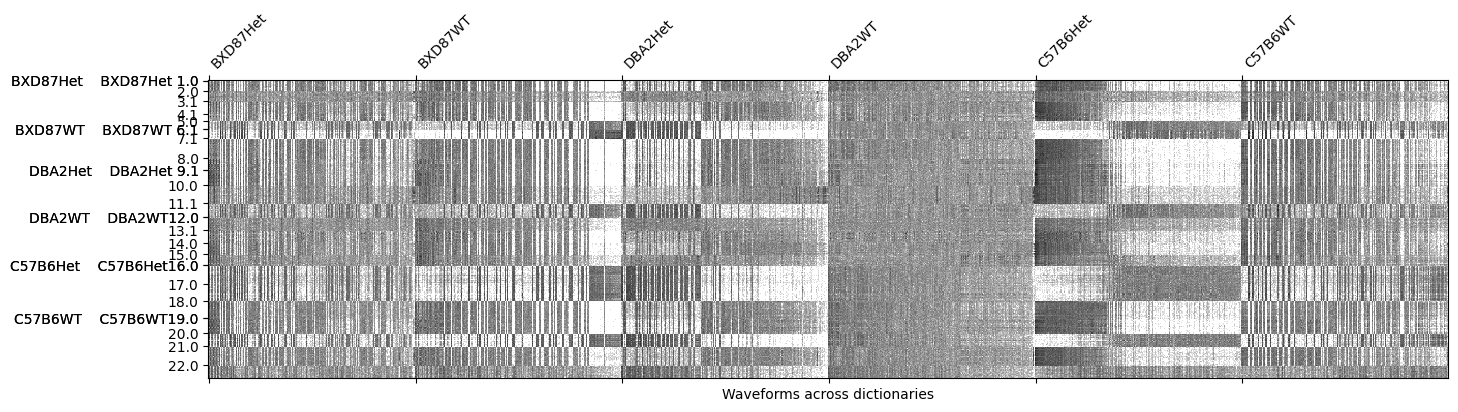

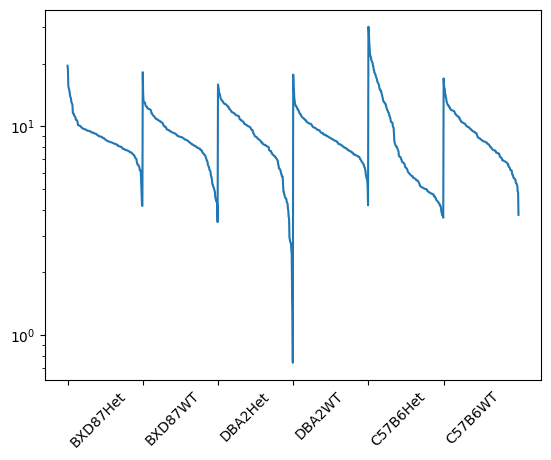

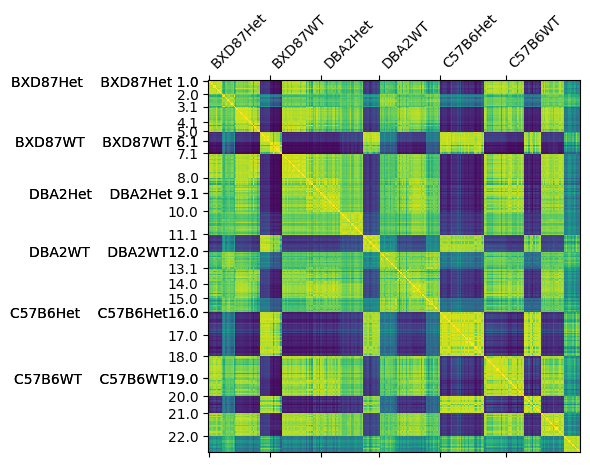

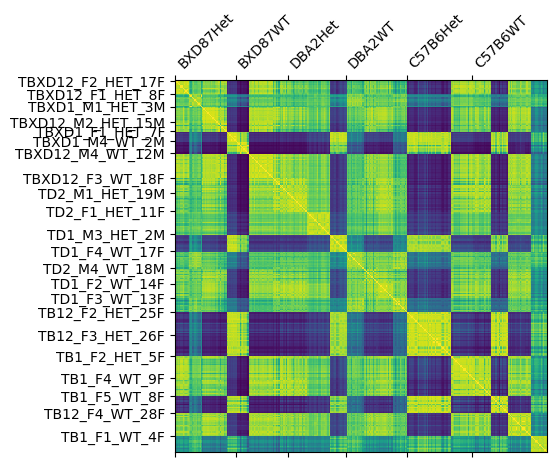

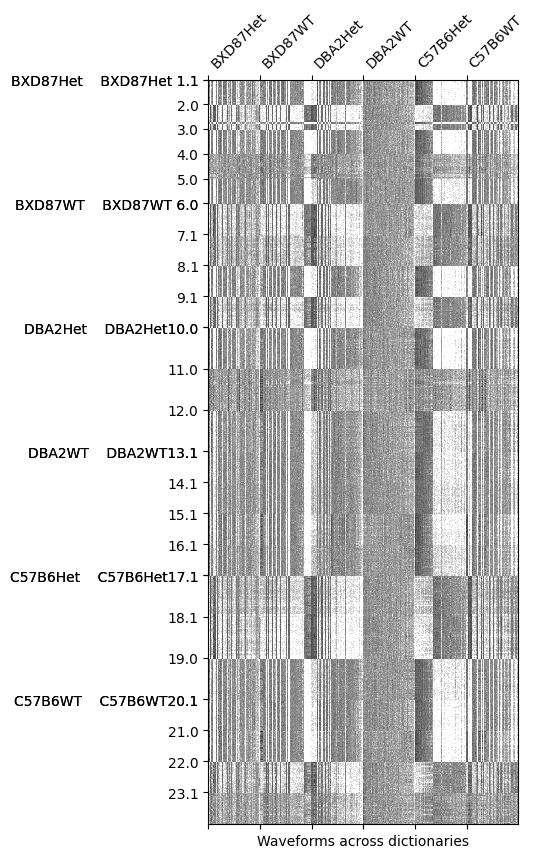

In [19]:
for split in range(1):#range(nsplits):
    for test_fold in range(1):#range(nfolds):
        segment_param_string = str(n_seg)+'_'+str(split)+str(test_fold)+dict_param_string        
        segment_info_train = pickle.load(open( "data/hpc_segment_info_valid_"+segment_param_string+".pickle", "rb" ) )
#        segment_info_train = pickle.load(open( "data/hpc_segment_info_train_"+segment_param_string+".pickle", "rb" ) )
        segment_info_test = pickle.load(open( "data/hpc_segment_info_test_"+segment_param_string+".pickle", "rb" ) )
        count_param_string = str(n_seg)+str(split)+str(test_fold)+dict_param_string
#        all_counts = pickle.load(open( "data/hpc_count_train_"+count_param_string+".pickle", "rb" ) )
        all_counts = pickle.load(open( "data/hpc_count_valid_"+count_param_string+".pickle", "rb" ) )
        counts_test = pickle.load(open( "data/hpc_count_test_"+count_param_string+".pickle", "rb" ) )
    
        
        label_train,subject_train,subject_index2name = get_labels_subjects(segment_info_train)
        label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        

        label_train,subject_train,subject_index2name = get_labels_subjects(segment_info_train)
        sex_train,sex_keys,subject_index2namesex = get_sex_labels(mice_df, subject_train,subject_index2name)
        label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        
        sex_test,_,subject_index2namesex_test = get_sex_labels(mice_df, subject_test,subject_index2name_test)

        X_train = np.hstack( [ np.vstack( [all_counts[d,s] for s in segment_info_train ] ) for d in segment_info_train]) 
        X_test = np.hstack( [ np.vstack( [np.array(counts_test[d,s]) for s in segment_info_test ] ) for d in segment_info_test])    

        label_string_list = [[str(s[-2])+str(s[-1])]*segment_info_train[s][0].shape[0]  for i,s in enumerate(segment_info_train)]

        sort_cols = lambda M : M[:,np.argsort(-np.sum(M,axis=0))]
        argsort_cols = lambda M : np.argsort(-np.sum(M,axis=0))
        
        col_sort_train = [ argsort_cols(np.vstack( [all_counts[d,s] for s in segment_info_train ] )) for d in segment_info_train]   
        count_matrix = np.hstack( [ sort_cols(np.vstack( [all_counts[d,s] for s in segment_info_train ] )) for d in segment_info_train])    
        
        max_2_plot = 6*48
        if len(label_train):
            rng = np.random.default_rng(0)
            a_subset = rng.choice(len(label_train),max_2_plot) 
        else:
            a_subset = np.arange(len(label_train)) 
        
        y_idx = np.argsort(subject_train[a_subset])
        indices_of_subset_sorted = a_subset[y_idx].squeeze()
        
        dictionary_cards = np.array([ all_counts[d,d].shape[1]  for d in segment_info_train])    
        dictionary_starts = np.cumsum(np.concatenate(([0],dictionary_cards[:-1])))
        
        subject_boundary = np.concatenate(([0],np.flatnonzero(np.diff(subject_train[ indices_of_subset_sorted])!=0)))
        subject_labels = 1+np.unique(subject_train[ indices_of_subset_sorted] + sex_train[indices_of_subset_sorted]/10)
        
        
        class_boundary = np.concatenate(([0],np.flatnonzero(np.diff(label_train[ indices_of_subset_sorted])!=0)))
        class_labels = [types[int(x)] for x in np.unique(label_train[ indices_of_subset_sorted])]
        merged_class_labels = [types[int(x)]+'    ' for x in np.unique(label_train[ indices_of_subset_sorted])]
        isin = np.isin(subject_boundary,class_boundary)
        for i in range(len(class_labels)):
            match_idx = np.flatnonzero(subject_boundary == class_boundary[i])
            if len(match_idx)==1:
                app = str(subject_labels[match_idx].squeeze())
                merged_class_labels[i] += merged_class_labels[i][:-len(app)] + app
                
        plt.matshow(np.log(1+count_matrix[indices_of_subset_sorted]),cmap='gray_r')#[:,idx])
        
        plt.xticks(dictionary_starts,labels=types,rotation=45,ha='left')
        plt.yticks(np.concatenate((subject_boundary,class_boundary)), labels=np.concatenate((subject_labels,merged_class_labels,)))
        plt.xlabel('Waveforms across dictionaries')
        
        plt.show()
        
        
        plt.semilogy((1+np.sum(count_matrix,axis=0))/(1+count_matrix.shape[0]))
        plt.xticks(dictionary_starts,labels=types,rotation=45,ha='left')
        plt.show()
        
        
        idf = 1-np.log((1+np.sum(count_matrix>0,axis=0,keepdims=True))/(1+count_matrix.shape[0]))
        ncount = count_matrix[indices_of_subset_sorted]*idf
        ncount /= np.sqrt(np.sum(ncount**2,axis=1,keepdims=True))
        
        #fig, axs = plt.subplots()
        plt.matshow(ncount@ncount.T)
        
        plt.xticks(class_boundary, labels=class_labels,rotation=45,ha='left')
        plt.yticks(np.concatenate((subject_boundary,class_boundary)), labels=np.concatenate((subject_labels,merged_class_labels,)))
        
        plt.show()
        
        
        plt.matshow(ncount@ncount.T)
        
        subject_labels = list(subject_index2namesex.values())
        plt.xticks(class_boundary, labels=class_labels,rotation=45,ha='left')
        plt.yticks(subject_boundary, labels=subject_labels)
        plt.show()
        #subject_index2name
        #subject_index2name
        
        valid_count_matrix = np.hstack( [ sort_cols(np.vstack( [np.array(counts_test[d,s]) for s in segment_info_test ] )) for d in segment_info_test])            
        indices_sorted = np.argsort(subject_test).squeeze()
        subject_boundary = np.concatenate(([0],np.flatnonzero(np.diff(subject_test)!=0)))
        subject_labels = 1+np.unique(subject_test + sex_test/10)
        
        class_boundary = np.concatenate(([0],np.flatnonzero(np.diff(label_test)!=0)))
        class_labels = [types[int(x)] for x in np.unique(label_test)]
        merged_class_labels = [types[int(x)]+'    ' for x in np.unique(label_test)]
        isin = np.isin(subject_boundary,class_boundary)
        for i in range(len(class_labels)):
            match_idx = np.flatnonzero(subject_boundary == class_boundary[i])
            if len(match_idx)==1:
                app = str(subject_labels[match_idx].squeeze())
                merged_class_labels[i] += merged_class_labels[i][:-len(app)] + app
                
        plt.matshow(np.log(1+valid_count_matrix[indices_sorted]),cmap='gray_r')
        plt.xticks(dictionary_starts,labels=types,rotation=45,ha='left')
        plt.yticks(np.concatenate((subject_boundary,class_boundary)), labels=np.concatenate((subject_labels,merged_class_labels,)))
        plt.xlabel('Waveforms across dictionaries')
        plt.show()


In [20]:
def plot_confusion_matrix(y,y_pred,labels,title,fname,cmap="Blues"):
    conf_matrix = confusion_matrix(y, y_pred)
    micro_acc = np.trace(conf_matrix)/np.sum(conf_matrix)
    conf_matrix_norm = conf_matrix/ conf_matrix.sum(axis=1, keepdims=True)
#    macro_acc = np.mean(np.diag(conf_matrix_norm))
#    conf_matrix_norm *= 100
    fig = plt.figure(figsize=np.array((6.4, 4.8))*len(labels)/3)
    cs= plt.matshow(conf_matrix_norm,cmap=cmap,vmin=0,vmax=1)#00)

    scale_colormaps = {'Blues':-0.5,"Grays":-0.5,"hot":0.4}
    for (i, j), z in np.ndenumerate(conf_matrix_norm):
        if z==0:
            continue
        color = 'w'
        if np.sign(scale_colormaps[cmap])*z>scale_colormaps[cmap]:
            color = 'b'
        plt.text(j, i, '{:0.2f}\n({})'.format(z,conf_matrix[i,j]), ha='center', va='center',color=color)
    
    plt.colorbar(cs)
    plt.xticks(np.arange(len(labels)),labels=labels,rotation='vertical')
    plt.yticks(np.arange(len(labels)),labels=labels)
#    plt.title(f'Accuracy (%) {title}. Macro: {100*macro_acc:.0f}% Micro (n={len(y)}): {100*micro_acc:.0f}%')
    plt.title(f'Accuracy {title}: {micro_acc:.2f} (n={len(y)})')
#    plt.savefig(fname+'.eps', format='eps',bbox_inches='tight')
    plt.savefig('./results/'+fname+'.pdf', bbox_inches='tight')
    return fig


In [21]:
def plot_confusion_matrix_CI(conf_mean,conf_lb,conf_ub,accs,labels,title,fname,cmap="Blues"):
    fig = plt.figure(figsize=np.array((6.4, 4.8))*len(labels)/3)
    cs= plt.matshow(conf_mean,cmap=cmap,vmin=0,vmax=1)#00)

    scale_colormaps = {'Blues':-0.5,"Grays":-0.5,"hot":0.4}
    for (i, j), z in np.ndenumerate(conf_mean):
        if z==0:
            continue
        color = 'w'
        if np.sign(scale_colormaps[cmap])*z>scale_colormaps[cmap]:
            color = 'b'
        plt.text(j, i, '{:0.2f}\n({:0.2f},{:0.2f})'.format(z,conf_lb[i,j],conf_ub[i,j]), ha='center', va='center',color=color)
    
    plt.colorbar(cs)
    plt.xticks(np.arange(len(labels)),labels=labels,rotation='vertical')
    plt.yticks(np.arange(len(labels)),labels=labels)
#    plt.title(f'Accuracy (%) {title}. Macro: {100*macro_acc:.0f}% Micro (n={len(y)}): {100*micro_acc:.0f}%')
    plt.title(f'Accuracy {title}: {accs[0]:.2f} CI:({accs[1]:0.2f},{accs[2]:0.2f})')
#    plt.savefig(fname+'.eps', format='eps',bbox_inches='tight')
    plt.savefig('./results/'+fname+'.pdf', bbox_inches='tight')
    return fig


In [22]:
from scipy import stats
def corrected_resampled_t_test(values, n_train, n_test):
    """
    Computes Nadeau and Bengio's Corrected Resampled t-test.
    Parameters:
    values (list/array): List of performance values (e.g., Acc_A - Acc_B) 
                              across all folds.
    n_train (int): Number of samples used for training in each fold.
    n_test (int): Number of samples used for testing in each fold.
    """
    values = np.array(values)
    k = len(values)
    mean_val = np.mean(values)
    variance = np.var(values, ddof=1)
    
    # The Correction Factor: (1/k + n_test/n_train)
    correction = (1/k) + (n_test / n_train)
    
    # Corrected Standard Error
    corrected_se = np.sqrt(correction * variance)   
    
    # p-value (two-tailed)
    # Degrees of freedom is k - 1
    df = k - 1
    # t-statistic
#    t_stat = mean_val / corrected_se
#    p_val = stats.t.sf(np.abs(t_stat), df) * 2
    
    # 95% Confidence Interval
    t_critical = stats.t.ppf(0.975, df)
    
    lower_ci = mean_val - (t_critical * corrected_se)
    upper_ci = mean_val + (t_critical * corrected_se)
    return mean_val, lower_ci, upper_ci
    

# Example Usage for a 5x2cv split on 1000 samples:
# In each fold, n_train = 500, n_test = 500
diffs = [0.02, 0.01, 0.03, -0.01, 0.02, 0.01, 0.04, 0.02, 0.01, 0.01]
mean, lb,ub = corrected_resampled_t_test(diffs, n_train=500, n_test=500)
print(mean,lb,ub)

0.016 -0.01602726004204757 0.04802726004204757


In [23]:
def conservative_z(values):
    # values should be M by 2 for 5 by 2 
    values = np.array(values)
    k = len(values)
    mean_val = np.mean(values)
    variance = 0.5*np.mean((values[:,0]-values[:,1])**2)
    corrected_se = np.sqrt(variance)   
    
    z_critical = stats.norm.ppf(0.975)
    
    lower_ci = mean_val - (z_critical * corrected_se)
    upper_ci = mean_val + (z_critical * corrected_se)
    return mean_val, lower_ci, upper_ci
    

# Example Usage for a 5x2cv split on 1000 samples:
# In each fold, n_train = 500, n_test = 500
diffs = np.array([[0.02, 0.01, 0.03, -0.01, 0.02],
         [0.01, 0.04, 0.02, 0.01, 0.01]]).T
mean, lb,ub = conservative_z(diffs)
print(mean,lb,ub)

0.016 -0.008791801292182464 0.04079180129218246


In [24]:
def corrected_resampled_t_test_LOO(acc,n,n_splits):
    #https://proceedings.neurips.cc/paper_files/paper/1999/file/7d12b66d3df6af8d429c1a357d8b9e1a-Paper.pdf
    n_folds = n_splits*n
    variance = n_folds/(n_folds-1)*acc*(1-acc)
#    variance = acc*n_folds*(n_folds-acc*n_folds)/n_folds/(n_folds-1)
    n_test = 1
    n_train = n-1
    correction = (1/n_folds) + (n_test / n_train)
    corrected_se = np.sqrt(correction * variance)   
    t_critical = stats.t.ppf(0.975, n_folds - 1)
    lower_ci = acc - (t_critical * corrected_se)
    upper_ci = acc + (t_critical * corrected_se)
    return acc, lower_ci, upper_ci
    
mean, lb,ub = corrected_resampled_t_test_LOO(0.9,17,5)
print(mean,lb,ub)
mean, lb,ub = corrected_resampled_t_test_LOO(0.5,17,5)
print(mean,lb,ub)

0.9 0.7364570401508836 1.0635429598491164
0.5 0.2274284002514727 0.7725715997485273


In [25]:
LOO = True

In [26]:
for use_spectral in [ False]:
    if use_spectral:
        dict_param_string = 'spectral_'+str(n_windows)+'_'+str(window_length)+'_'+str(n_centroids)
    else:
        dict_param_string = str(n_windows)+'_'+str(window_length)+'_'+str(n_centroids)+'_'+str(centroid_len)+'_'+str_si
            
    for task_str in ['type','strain','tsc']:
        all_pred = dict()
        all_pred_maj = dict()
        all_pred_pooled = dict()
        all_labels = dict()
        all_labels_pooled = dict()
        
        for split in range(nsplits):
            for test_fold in range(nfolds):
                segment_param_string = str(n_seg)+'_'+str(split)+str(test_fold)+dict_param_string        
    #            segment_info_train = pickle.load(open( "data/hpc_segment_info_train_"+segment_param_string+".pickle", "rb" ) )
    #            _,_,subject_index2name = get_labels_subjects(segment_info_train)
                segment_info_test = pickle.load(open( "data/hpc_segment_info_test_"+segment_param_string+".pickle", "rb" ) )
                count_param_string = str(n_seg)+str(split)+str(test_fold)+dict_param_string
                counts_test = pickle.load(open( "data/hpc_count_test_"+count_param_string+".pickle", "rb" ) )
                label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        
                X_test = np.hstack( [ np.vstack( [counts_test[d,s] for s in segment_info_test ] ) for d in segment_info_test])    
                # Load classifier
                filename = 'models/classifiers_l2_'+pool_str+count_param_string+task_str+ 'LOO' if LOO else ''
    #            filename = 'models/hpc_classifiers_across_folds_l2_'+count_param_string+task_str+ 'LOO' if LOO else ''
                print(filename)
                pipes = pickle.load(open(filename+".pkl", "rb")) 
        
                # Prepare prediction 
                if task_str =='type':
                    y_all = label_test.copy()
                elif task_str =='strain':
                    y_all = label_test // 2
                elif task_str =='tsc':
                    y_all = label_test % 2
                
                y_pred = np.zeros_like(y_all)
                subs_in_test, indices = np.unique(subject_test,return_index=True)
                y_test_pooled = y_all[indices]        
                y_pred_maj = np.zeros_like(subs_in_test)
                y_pred_pooled = np.zeros_like(subs_in_test)
        
                all_labels[split,test_fold] = y_all.copy()
                all_labels_pooled[split,test_fold] = y_test_pooled.copy()
                
                if LOO:
                    n_groups = len(np.unique(subject_test))
                else:
                    n_groups = 5
                    # two fold based on dictionary (done 5 random splits)
                    # five fold on the test
                    # Together this is
                    # 1/2 + 4/5*1/2 = 5/10+4/10 = 9/10 of mice in training, 1/5*1/2 = 1/10 of mice test
                    # for each dictionary we get results for 1/2 mice in test
                group_kfold_test = StratifiedGroupKFold(n_splits=n_groups)
                
                for k, (train_index, test_index) in enumerate(group_kfold_test.split(X_test, label_test, subject_test)):        
                    X = X_test[test_index]
                    y = y_all[test_index]
                    
                    groups = subject_test[test_index]
                    subs_in_test, indices,inverses = np.unique(groups,return_index=True, return_inverse=True)
                
                    pipe_i = pipes[k]
                    
                    y_pred[test_index] =  pipe_i.predict(X)
                    test_acc =  pipe_i.score(X,y) # each window independently 
        
                   # pooling counts per mouse 
                    ypooled = y[indices]
                    Xpooled = X[indices].copy()
                    for l,index in enumerate(indices):
                        Xpooled[l] = np.sum(X[inverses==l],axis=0)
                    
                    test_acc_pooled =  pipe_i.score(Xpooled,ypooled)
                    for sub in subs_in_test:
                        y_pred_pooled[sub] = pipe_i.predict(Xpooled[sub == subs_in_test])[0]
                
                    for l,index in enumerate(indices):
                        sub = subs_in_test[l]
                        y_pred_maj[sub] = np.argmax(np.sum(pipe_i.predict_log_proba(X[inverses==l]),axis=0))
                    
                    test_acc_maj =  np.mean(y_pred_maj[subs_in_test]==y_test_pooled[subs_in_test] )
    #                print(f"Fold {k}: C={pipe_i.named_steps['clf'].get_params()['C']:6.3g}"
    #                        +f" Ave.Acc.={test_acc:4.2f} Pool Acc.={test_acc_pooled:4.2f} Maj. Acc.={test_acc_maj:4.2f}")    
                all_pred[split,test_fold] = y_pred.copy()
                all_pred_pooled[split,test_fold] = y_pred_pooled.copy()
                all_pred_maj[split,test_fold] = y_pred_maj.copy()
        
        if task_str=='type':     
            the_labels = types
            file_prefix = 'type'
        elif task_str=='strain':
            the_labels = strains
            file_prefix = 'bg'
        elif task_str=='tsc':
            the_labels = tscs
            file_prefix = 'tsc'
        micro_acc = np.zeros((nsplits,nfolds))
        micro_acc_2 = np.zeros((nsplits))
    
        conf_matrix_norm = np.zeros((nsplits,nfolds,len(the_labels),len(the_labels)))
    #    conf_matrix_sum = np.zeros((nsplits,nfolds,len(the_labels)))
        micro_acc_2_strain = np.zeros((nsplits,3))
        all_accuracies = []
        for split in range(nsplits):
            for test_fold in range(nfolds): 
                y = all_labels_pooled[split,test_fold]
                y_pred = all_pred_pooled[split,test_fold]
                conf_matrix = confusion_matrix(y, y_pred)
                micro_acc[split,test_fold] = np.trace(conf_matrix)/np.sum(conf_matrix)
                conf_matrix_norm[split,test_fold] = conf_matrix/ conf_matrix.sum(axis=1, keepdims=True)
     #           conf_matrix_sum[split,test_fold] = conf_matrix.sum(axis=1)
                
            
            y_test = np.concatenate([all_labels[split,test_fold] for test_fold in range(nfolds) ])
            y_pred = np.concatenate([all_pred[split,test_fold] for test_fold in range(nfolds) ])
            y_test_pooled = np.concatenate([all_labels_pooled[split,test_fold] for test_fold in range(nfolds) ])
            y_pred_pooled = np.concatenate([all_pred_pooled[split,test_fold] for test_fold in range(nfolds) ])
            all_accuracies.append(y_pred_pooled==y_test_pooled)        
            micro_acc_2[split]=np.mean(y_pred_pooled==y_test_pooled)
            for strain_idx in range(3):
                if task_str=='strain':
                    micro_acc_2_strain[split,strain_idx]=np.mean(y_pred_pooled[y_test_pooled == strain_idx]==y_test_pooled[y_test_pooled == strain_idx])
                    y_test_strain = y_test_pooled
                elif task_str=='type':
                    micro_acc_2_strain[split,strain_idx]=np.mean(y_pred_pooled[y_test_pooled//2 == strain_idx]==y_test_pooled[y_test_pooled//2 == strain_idx])
                else:
                    micro_acc_2_strain[split,strain_idx]=np.mean(y_pred_pooled[y_test_strain == strain_idx]==y_test_pooled[y_test_strain == strain_idx])    

       
        n = 45
        n_in_splits = np.array([17,14,14])[np.newaxis,:]
        print(micro_acc_2,np.mean(micro_acc_2),np.std(micro_acc_2,ddof=1),np.mean(micro_acc_2)+np.array([-1,1])*np.std(micro_acc_2,ddof=1)*np.sqrt((1/nsplits+n/(n-1)))*stats.t.ppf(0.975, nsplits - 1))
        print(np.mean(micro_acc_2_strain,axis=0),np.std(micro_acc_2_strain,axis=0,ddof=1),\
              np.mean(micro_acc_2_strain,axis=0)+np.array([-1,1])[:,np.newaxis]*\
              np.std(micro_acc_2_strain,axis=0,keepdims=True,ddof=1)*\
              np.sqrt((1/nsplits+n_in_splits/(n_in_splits-1)))*stats.t.ppf(0.975, nsplits - 1))




models/classifiers_l2_48000100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48001100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48010100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48011100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48020100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48021100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48030100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48031100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48040100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48041100000_512_200_256_sv_sph_svdtypeLOO
[0.37777778 0.35555556 0.35555556 0.35555556 0.28888889] 0.3466666666666667 0.033701668640229124 [0.24319885 0.45013449]
[0.18823529 0.54285714 0.34285714] [0.0766965  0.0814411  0.07824608] [[-0.05103034  0.28734291  0.09736701]
 [ 0.42750093  0.79837138  0.58834728]]
models/classifiers_l2_48000100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48

models/classifiers_l2_48000100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48001100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48010100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48011100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48020100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48021100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48030100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48031100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48040100000_512_200_256_sv_sph_svdtypeLOO
models/classifiers_l2_48041100000_512_200_256_sv_sph_svdtypeLOO
(0.34723320158102766, 0.23826293241768126, 0.45620347074437406)
(0.3466666666666667, 0.19173145231289324, 0.5016018810204401)
models/classifiers_l2_48000100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48001100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48010100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48011100000_51

<Figure size 1280x960 with 0 Axes>

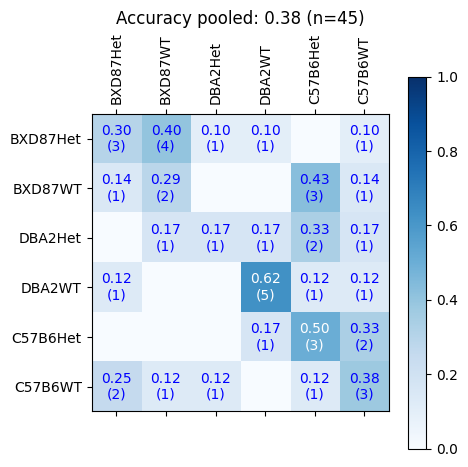

<Figure size 1280x960 with 0 Axes>

<Figure size 1280x960 with 0 Axes>

<Figure size 1280x960 with 0 Axes>

<Figure size 1280x960 with 0 Axes>

<Figure size 640x480 with 0 Axes>

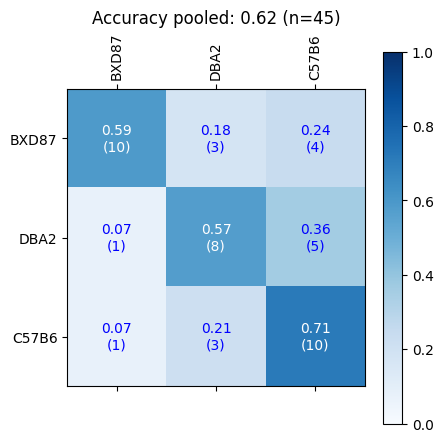

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 426.667x320 with 0 Axes>

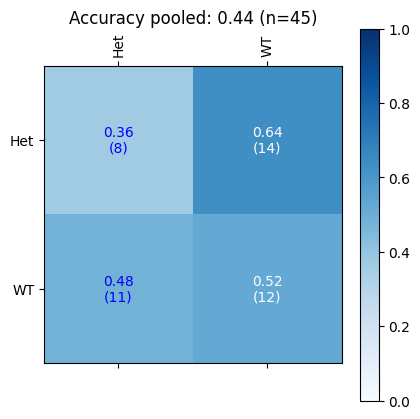

<Figure size 426.667x320 with 0 Axes>

<Figure size 426.667x320 with 0 Axes>

<Figure size 426.667x320 with 0 Axes>

<Figure size 426.667x320 with 0 Axes>

In [27]:


for task_str in ['type','strain','tsc']:
    all_pred = dict()
    all_pred_maj = dict()
    all_pred_pooled = dict()
    all_labels = dict()
    all_labels_pooled = dict()
    
    for split in range(nsplits):
        for test_fold in range(nfolds):
            segment_param_string = str(n_seg)+'_'+str(split)+str(test_fold)+dict_param_string        
#            segment_info_train = pickle.load(open( "data/hpc_segment_info_train_"+segment_param_string+".pickle", "rb" ) )
#            _,_,subject_index2name = get_labels_subjects(segment_info_train)
            segment_info_test = pickle.load(open( "data/hpc_segment_info_test_"+segment_param_string+".pickle", "rb" ) )
            count_param_string = str(n_seg)+str(split)+str(test_fold)+dict_param_string
            counts_test = pickle.load(open( "data/hpc_count_test_"+count_param_string+".pickle", "rb" ) )
            label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        
            X_test = np.hstack( [ np.vstack( [counts_test[d,s] for s in segment_info_test ] ) for d in segment_info_test])    
            # Load classifier
            filename = 'models/classifiers_l2_'+pool_str+count_param_string+task_str+ 'LOO' if LOO else ''
#            filename = 'models/hpc_classifiers_across_folds_l2_'+count_param_string+task_str+ 'LOO' if LOO else ''
            print(filename)
            pipes = pickle.load(open(filename+".pkl", "rb")) 
    
            # Prepare prediction 
            if task_str =='type':
                y_all = label_test.copy()
            elif task_str =='strain':
                y_all = label_test // 2
            elif task_str =='tsc':
                y_all = label_test % 2
            
            y_pred = np.zeros_like(y_all)
            subs_in_test, indices = np.unique(subject_test,return_index=True)
            y_test_pooled = y_all[indices]        
            y_pred_maj = np.zeros_like(subs_in_test)
            y_pred_pooled = np.zeros_like(subs_in_test)
    
            all_labels[split,test_fold] = y_all.copy()
            all_labels_pooled[split,test_fold] = y_test_pooled.copy()
            
            if LOO:
                n_groups = len(np.unique(subject_test))
            else:
                n_groups = 5
                # two fold based on dictionary (done 5 random splits)
                # five fold on the test
                # Together this is
                # 1/2 + 4/5*1/2 = 5/10+4/10 = 9/10 of mice in training, 1/5*1/2 = 1/10 of mice test
                # for each dictionary we get results for 1/2 mice in test
            group_kfold_test = StratifiedGroupKFold(n_splits=n_groups)
            
            for k, (train_index, test_index) in enumerate(group_kfold_test.split(X_test, label_test, subject_test)):        
                X = X_test[test_index]
                y = y_all[test_index]
                
                groups = subject_test[test_index]
                subs_in_test, indices,inverses = np.unique(groups,return_index=True, return_inverse=True)
            
                pipe_i = pipes[k]
                
                y_pred[test_index] =  pipe_i.predict(X)
                test_acc =  pipe_i.score(X,y) # each window independently 
    
               # pooling counts per mouse 
                ypooled = y[indices]
                Xpooled = X[indices].copy()
                for l,index in enumerate(indices):
                    Xpooled[l] = np.sum(X[inverses==l],axis=0)
                
                test_acc_pooled =  pipe_i.score(Xpooled,ypooled)
                for sub in subs_in_test:
                    y_pred_pooled[sub] = pipe_i.predict(Xpooled[sub == subs_in_test])[0]
            
                for l,index in enumerate(indices):
                    sub = subs_in_test[l]
                    y_pred_maj[sub] = np.argmax(np.sum(pipe_i.predict_log_proba(X[inverses==l]),axis=0))
                
                test_acc_maj =  np.mean(y_pred_maj[subs_in_test]==y_test_pooled[subs_in_test] )
#                print(f"Fold {k}: C={pipe_i.named_steps['clf'].get_params()['C']:6.3g}"
#                        +f" Ave.Acc.={test_acc:4.2f} Pool Acc.={test_acc_pooled:4.2f} Maj. Acc.={test_acc_maj:4.2f}")    
            all_pred[split,test_fold] = y_pred.copy()
            all_pred_pooled[split,test_fold] = y_pred_pooled.copy()
            all_pred_maj[split,test_fold] = y_pred_maj.copy()
    
    if task_str=='type':     
        the_labels = types
        file_prefix = 'type'
    elif task_str=='strain':
        the_labels = strains
        file_prefix = 'bg'
    elif task_str=='tsc':
        the_labels = tscs
        file_prefix = 'tsc'
    micro_acc = np.zeros((nsplits,nfolds))
    conf_matrix_norm = np.zeros((nsplits,nfolds,len(the_labels),len(the_labels)))
#    conf_matrix_sum = np.zeros((nsplits,nfolds,len(the_labels)))
    all_accuracies = []
    for split in range(nsplits):
        for test_fold in range(nfolds): 
            y = all_labels_pooled[split,test_fold]
            y_pred = all_pred_pooled[split,test_fold]
            conf_matrix = confusion_matrix(y, y_pred)
            micro_acc[split,test_fold] = np.trace(conf_matrix)/np.sum(conf_matrix)
            conf_matrix_norm[split,test_fold] = conf_matrix/ conf_matrix.sum(axis=1, keepdims=True)
 #           conf_matrix_sum[split,test_fold] = conf_matrix.sum(axis=1)
            
        
        y_test = np.concatenate([all_labels[split,test_fold] for test_fold in range(nfolds) ])
        y_pred = np.concatenate([all_pred[split,test_fold] for test_fold in range(nfolds) ])
        y_test_pooled = np.concatenate([all_labels_pooled[split,test_fold] for test_fold in range(nfolds) ])
        y_pred_pooled = np.concatenate([all_pred_pooled[split,test_fold] for test_fold in range(nfolds) ])
        y_pred_maj = np.concatenate([all_pred_maj[split,test_fold] for test_fold in range(nfolds) ])
        all_accuracies.append(y_pred_pooled==y_test_pooled)        
        run_name = str(n_seg)+pool_str+str(split)+dict_param_string
        fig1=plot_confusion_matrix(y_test_pooled,y_pred_pooled,the_labels,"pooled",file_prefix+run_name+"_pooled")
        
        if split>0:
             plt.close()


    # Compute the 5x2cv test
    
    n = 45
    # n_classes = conf_matrix_norm.shape[2]
    # conf_entries = conf_matrix_norm.reshape(-1,n_classes,n_classes)
    # a_mean = np.zeros((n_classes,n_classes))
    # a_lb = np.zeros((n_classes,n_classes))
    # a_ub = np.zeros((n_classes,n_classes))
    # for (i, j), _ in np.ndenumerate(conf_matrix):
    #     a_mean[i,j], a_lb[i,j], a_ub[i,j] = corrected_resampled_t_test(conf_entries[:,i,j],n-1,n/2)
    acc_info = corrected_resampled_t_test(micro_acc.ravel(),n-1,n/2)
#    run_name = str(n_seg)+pool_str+'CI'+dict_param_string
    print(acc_info)
    acc_info = corrected_resampled_t_test(np.concatenate(all_accuracies),n-1,1)
#    run_name = str(n_seg)+pool_str+'CI'+dict_param_string
    print(acc_info)
#    fig1=plot_confusion_matrix_CI(a_mean,a_lb,a_ub,acc_info,the_labels,"pooled",file_prefix+run_name+"_pooled")  
        




models/classifiers_l2_48000100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48000100000_512_200_256_sv_sph_svdtscLOO
models/classifiers_l2_48001100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48001100000_512_200_256_sv_sph_svdtscLOO
models/classifiers_l2_48010100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48010100000_512_200_256_sv_sph_svdtscLOO
models/classifiers_l2_48011100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48011100000_512_200_256_sv_sph_svdtscLOO
models/classifiers_l2_48020100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48020100000_512_200_256_sv_sph_svdtscLOO
models/classifiers_l2_48021100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48021100000_512_200_256_sv_sph_svdtscLOO
models/classifiers_l2_48030100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48030100000_512_200_256_sv_sph_svdtscLOO
models/classifiers_l2_48031100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_480311000

<Figure size 1280x960 with 0 Axes>

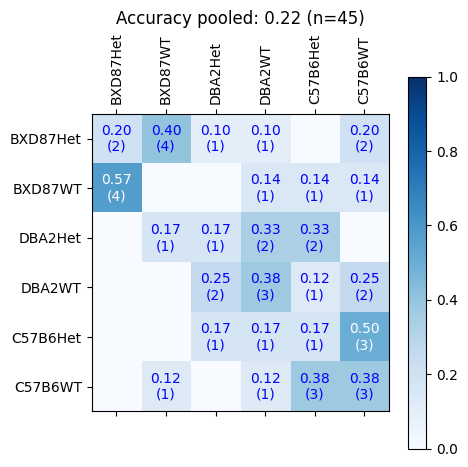

<Figure size 640x480 with 0 Axes>

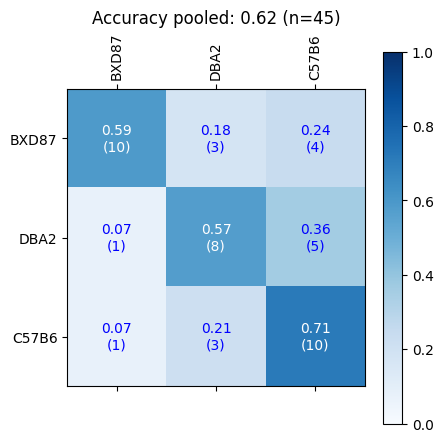

<Figure size 426.667x320 with 0 Axes>

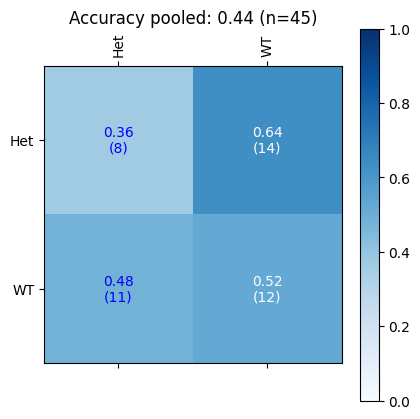

<Figure size 1280x960 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 426.667x320 with 0 Axes>

<Figure size 1280x960 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 426.667x320 with 0 Axes>

<Figure size 1280x960 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 426.667x320 with 0 Axes>

In [28]:
all_pred = dict()
all_pred_maj = dict()
all_pred_pooled = dict()
all_labels = dict()
all_labels_pooled = dict()

task_str = 'type'

for split in range(nsplits):
    for test_fold in range(nfolds):
        segment_param_string = str(n_seg)+'_'+str(split)+str(test_fold)+dict_param_string        
#        segment_info_train = pickle.load(open( "data/hpc_segment_info_train_"+segment_param_string+".pickle", "rb" ) )
 #       _,_,subject_index2name = get_labels_subjects(segment_info_train)
        segment_info_test = pickle.load(open( "data/hpc_segment_info_test_"+segment_param_string+".pickle", "rb" ) )
        count_param_string = str(n_seg)+str(split)+str(test_fold)+dict_param_string
        counts_test = pickle.load(open( "data/hpc_count_test_"+count_param_string+".pickle", "rb" ) )
    
        
        label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        
        X_test = np.hstack( [ np.vstack( [np.array(counts_test[d,s]) for s in segment_info_test ] ) for d in segment_info_test])    

        # Load classifier
        filename = 'models/classifiers_l2_'+pool_str+count_param_string+'strain'+ 'LOO' if LOO else ''
        print(filename)
        strain_pipes = pickle.load(open(filename+".pkl", "rb")) 

        filename = 'models/classifiers_l2_'+pool_str+count_param_string+'tsc'+ 'LOO' if LOO else ''
        print(filename)
        bg_pipes = pickle.load(open(filename+".pkl", "rb")) 

        # Prepare prediction 
        y_pred = np.zeros_like(label_test)
        subs_in_test, indices = np.unique(subject_test,return_index=True)
        y_test_pooled = label_test[indices].copy()        
        y_pred_maj = np.zeros_like(subs_in_test)
        y_pred_pooled = np.zeros_like(subs_in_test)

        all_labels[split,test_fold] = label_test.copy()
        all_labels_pooled[split,test_fold] = y_test_pooled.copy()
        
        if LOO:
            n_groups = len(np.unique(subject_test))
        else:
            n_groups = 5
        group_kfold_test = StratifiedGroupKFold(n_splits=n_groups)
        
        for k, (train_index, test_index) in enumerate(group_kfold_test.split(X_test, label_test, subject_test)):        
            X = X_test[test_index]
            y = label_test[test_index]
            
            groups = subject_test[test_index]
            subs_in_test, indices,inverses = np.unique(groups,return_index=True, return_inverse=True)
        
            strain_pipe_i = strain_pipes[k]
            bg_pipe_i = bg_pipes[k]
            def joined_predict(X):
                return 2*strain_pipe_i.predict(X) + bg_pipe_i.predict(X)

            def joined_log_proba(X):
                return np.kron(strain_pipe_i.predict_log_proba(X),np.ones((1,2))) + np.kron(np.ones((1,3)),bg_pipe_i.predict_log_proba(X))

            y_pred[test_index] = joined_predict(X)
            test_acc =  np.mean(y==y_pred[test_index]) # each window independently 

           # pooling counts per mouse 
            ypooled = y[indices]
            Xpooled = X[indices].copy()
            for l,index in enumerate(indices):
                Xpooled[l] = np.sum(X[inverses==l],axis=0)
            
            test_acc_pooled =  pipe_i.score(Xpooled,ypooled)
            for sub in subs_in_test:
                y_pred_pooled[sub] = joined_predict(Xpooled[sub == subs_in_test])[0]
        
            for l,index in enumerate(indices):
                sub = subs_in_test[l]
                y_pred_maj[sub] = np.argmax(np.sum(joined_log_proba(X[inverses==l]),axis=0))
            
            test_acc_maj =  np.mean(y_pred_maj[subs_in_test]==y_test_pooled[subs_in_test] )
#            print(f"Fold {k}: C={strain_pipe_i.named_steps['clf'].get_params()['C']:6.3g}"
#                        +f" Ave.Acc.={test_acc:4.2f} Pool Acc.={test_acc_pooled:4.2f} Maj. Acc.={test_acc_maj:4.2f}")    
        all_pred[split,test_fold] = y_pred.copy()
        all_pred_pooled[split,test_fold] = y_pred_pooled.copy()
        all_pred_maj[split,test_fold] = y_pred_maj.copy()


for split in range(nsplits):
    y_test = np.concatenate([all_labels[split,test_fold] for test_fold in range(nfolds) ])
    y_pred = np.concatenate([all_pred[split,test_fold] for test_fold in range(nfolds) ])
    y_test_pooled = np.concatenate([all_labels_pooled[split,test_fold] for test_fold in range(nfolds) ])
    y_pred_pooled = np.concatenate([all_pred_pooled[split,test_fold] for test_fold in range(nfolds) ])
    y_pred_maj = np.concatenate([all_pred_maj[split,test_fold] for test_fold in range(nfolds) ])
    run_name = str(n_seg)+pool_str+str(split)+dict_param_string
#    plot_confusion_matrix(y_test_pooled,y_pred_maj,the_labels,"pooled",task_str+run_name)
 #   plot_confusion_matrix(y_test,y_pred,the_labels,"ave 1 hour",task_str+run_name)
    plot_confusion_matrix(y_test_pooled,y_pred_pooled,types,"pooled",'indep'+task_str+run_name+"_pooled")
    if split>0:
         plt.close()
    plot_confusion_matrix(y_test_pooled//2,y_pred_pooled//2,strains,"pooled",'indep'+'_bg_'+task_str+run_name+"_pooled")
    if split>0:
         plt.close()
    plot_confusion_matrix(y_test_pooled%2,y_pred_pooled%2,tscs,"pooled",'indep'+'_tsc_'+task_str+run_name+"_pooled")
    if split>0:
         plt.close()
        
    # plot_confusion_matrix(y_test_pooled,y_pred_maj,types,"maj.",'indep'+task_str+run_name+"_maj")
    # if split>0:
    #      plt.close()
    # plot_confusion_matrix(y_test_pooled//2,y_pred_maj//2,strains,"maj.",'indep'+'_bg_'+task_str+run_name+"_maj")
    # if split>0:
    #      plt.close()
    # plot_confusion_matrix(y_test_pooled%2,y_pred_maj%2,tscs,"maj.",'indep'+'_tsc_'+task_str+run_name+"_maj")
    # if split>0:
    #      plt.close()
        




models/classifiers_l2_48000100000_512_200_256_sv_sph_svdtsc_on_strainLOO
models/classifiers_l2_48001100000_512_200_256_sv_sph_svdtsc_on_strainLOO
models/classifiers_l2_48010100000_512_200_256_sv_sph_svdtsc_on_strainLOO


divide by zero encountered in log


models/classifiers_l2_48011100000_512_200_256_sv_sph_svdtsc_on_strainLOO
models/classifiers_l2_48020100000_512_200_256_sv_sph_svdtsc_on_strainLOO
models/classifiers_l2_48021100000_512_200_256_sv_sph_svdtsc_on_strainLOO


divide by zero encountered in log


models/classifiers_l2_48030100000_512_200_256_sv_sph_svdtsc_on_strainLOO
models/classifiers_l2_48031100000_512_200_256_sv_sph_svdtsc_on_strainLOO


...

divide by zero encountered in log


models/classifiers_l2_48041100000_512_200_256_sv_sph_svdtsc_on_strainLOO


divide by zero encountered in log


[0 0 0 ... 5 5 5]
[0.4665625  0.79197917 0.58135417] [0.08182671 0.01334797 0.04541028] [[0.21129244 0.75010108 0.43888346]
 [0.72183256 0.83385725 0.72382488]]
[0.55020833 0.38291667 0.666875   0.91708333 0.548125   0.61458333] [0.04847053 0.12091771 0.02574203 0.02078902 0.0707774  0.03316199] [[0.42797382 0.11486463 0.60874379 0.86496335 0.38829392 0.53144315]
 [0.67244284 0.65096871 0.72500621 0.96920332 0.70795608 0.69772352]]
[0.49411765 0.84285714 0.62857143] [0.06706914 0.05976143 0.03194383] [[0.28488592 0.65536095 0.5283505 ]
 [0.70334937 1.03035333 0.72879236]]
[0.54       0.42857143 0.63333333 1.         0.63333333 0.625     ] [0.05477226 0.10101525 0.13944334 0.         0.0745356  0.        ] [[0.4018736  0.20463943 0.31843932 1.         0.4650154  0.625     ]
 [0.6781264  0.65250342 0.94822735 1.         0.80165127 0.625     ]]


<Figure size 1280x960 with 0 Axes>

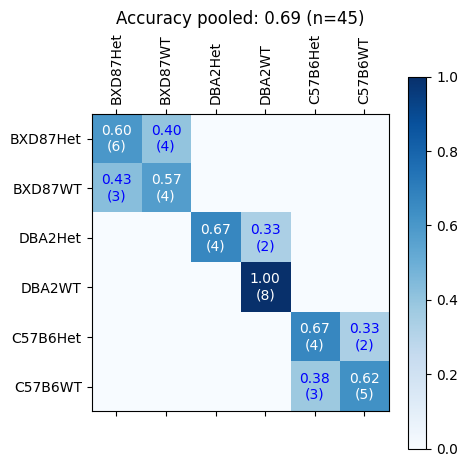

<Figure size 1280x960 with 0 Axes>

<Figure size 1280x960 with 0 Axes>

<Figure size 1280x960 with 0 Axes>

<Figure size 1280x960 with 0 Axes>

In [30]:
for use_spectral in [ False]:
    if use_spectral:
        dict_param_string = 'spectral_'+str(n_windows)+'_'+str(window_length)+'_'+str(n_centroids)
    else:
        dict_param_string = str(n_windows)+'_'+str(window_length)+'_'+str(n_centroids)+'_'+str(centroid_len)+'_'+str_si
            
    for task_str in ['tsc_on_strain']:#,'strain_on_tsc']:#,'tsc_on_strain']:
        all_pred = dict()
        all_pred_maj = dict()
        all_pred_pooled = dict()
        all_prob_pooled = dict()
        all_labels = dict()
        all_labels_pooled = dict()
        
        for split in range(nsplits):
            for test_fold in range(nfolds):
                segment_param_string = str(n_seg)+'_'+str(split)+str(test_fold)+dict_param_string        
                segment_info_test = pickle.load(open( "data/hpc_segment_info_test_"+segment_param_string+".pickle", "rb" ) )
                count_param_string = str(n_seg)+str(split)+str(test_fold)+dict_param_string
                counts_test = pickle.load(open( "data/hpc_count_test_"+count_param_string+".pickle", "rb" ) )
            
                label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        
    
                subs_in_test, indices = np.unique(subject_test,return_index=True)
                y_test_pooled = label_test[indices].copy()        
                # Prepare prediction 
                y_pred = np.zeros_like(label_test)
                y_pred_maj = np.zeros_like(subs_in_test)
                y_pred_pooled = np.zeros_like(subs_in_test)
                y_prob_pooled = np.zeros(subs_in_test.shape)
        
    
                if task_str =='strain_on_tsc':
                    given_test = label_test %  2
                    cond_test = label_test // 2
                    label_offset = label_test % 2
                    label_offset_pooled = y_test_pooled % 2
                    def label_remap(v):
                        return v*2
                    set_of_given = np.arange(2)
                elif task_str =='tsc_on_strain':
                    given_test = label_test //  2
                    cond_test = label_test % 2                
                    label_inv_map = given_test*2
                    label_offset = (label_test // 2)*2
                    label_offset_pooled = (y_test_pooled//2 )*2
                    def label_remap(v):
                        return v
                    set_of_given = np.arange(3)
        
                cond_test_pooled = cond_test[indices]        
                X_test = np.hstack( [ np.vstack( [counts_test[d,s] for s in segment_info_test ] ) for d in segment_info_test])    
    
                if LOO:
                    n_groups = len(np.unique(subject_test))
                else:
                    n_groups = 5
    
                group_kfold_test = StratifiedGroupKFold(n_splits=n_groups)
                # Load classifier
    #            filename = 'models/hpc_ave_classifiers_across_folds_l2_'+count_param_string+task_str
    #            filename = 'models/hpc_classifiers_across_folds_l2_'+count_param_string+task_str+ 'LOO' if LOO else ''
                filename = 'models/classifiers_l2_'+pool_str+count_param_string+task_str+ 'LOO' if LOO else ''
                
                print(filename)
                pipes = pickle.load(open(filename+".pkl", "rb")) 
                sub2pipe = {}
                for k, (train_index, test_index) in enumerate(group_kfold_test.split(X_test, label_test, subject_test)):    
    #                print([(i,j) for i,j in zip(orig_label[test_index],given_test[test_index])])
                    given_labels = given_test[test_index]
                    for given_label in set_of_given:
                        pipe_i = pipes[k][given_label]
                        X = X_test[test_index[given_labels==given_label]]
                        if X.shape[0]==0:
                            continue
                        y = cond_test[test_index[given_labels==given_label]]
                        
                        groups = subject_test[test_index[given_labels==given_label]]
                        subs_in_test, indices,inverses = np.unique(groups,return_index=True, return_inverse=True)
    
    
                        sub2pipe[subs_in_test[0]]=k
                        
                        y_pred[test_index[given_labels==given_label]] =  pipe_i.predict(X)
                        test_acc =  pipe_i.score(X,y) # each window independently 
            
                       # pooling counts per mouse 
                        ypooled = y[indices]
                        Xpooled = X[indices].copy()
                        for l,index in enumerate(indices):
                            Xpooled[l] = np.sum(X[inverses==l],axis=0)
                        
                        test_acc_pooled =  pipe_i.score(Xpooled,ypooled)
                        for sub in subs_in_test:
                            y_pred_pooled[sub] = pipe_i.predict(Xpooled[sub == subs_in_test])[0]
                            y_prob_pooled[sub] = pipe_i.predict_proba(Xpooled[sub == subs_in_test])[0,0]
    
                        test_acc_pooled2 =  np.mean(y_pred_pooled[subs_in_test]==cond_test_pooled[subs_in_test] )
                        for l,index in enumerate(indices):
                            sub = subs_in_test[l]
                            y_pred_maj[sub] = np.argmax(np.sum(pipe_i.predict_log_proba(X[inverses==l]),axis=0))
                        
                        test_acc_maj =  np.mean(y_pred_maj[subs_in_test]==cond_test_pooled[subs_in_test] )
    #                    print(f"Fold {k} conditional {given_label}: C={pipe_i.named_steps['clf'].get_params()['C']:6.3g}"
    #                            +f" Ave.Acc.={test_acc:4.2f} Pool Acc.={test_acc_pooled2:4.2f} Maj. Acc.={test_acc_maj:4.2f}")    
    
                filename = 'models/classifiers_l2_'+pool_str+count_param_string+ 'LOO' if LOO else ''
                pickle.dump(sub2pipe,open(filename+"_fold2pipe.pkl", "wb")) 
                all_pred[split,test_fold] = label_remap(y_pred)+label_offset
                all_pred_pooled[split,test_fold] = label_remap(y_pred_pooled)+label_offset_pooled
                all_pred_maj[split,test_fold] = label_remap(y_pred_maj)+label_offset_pooled
                all_labels_pooled[split,test_fold] = y_test_pooled.copy()
                all_labels[split,test_fold] = label_test.copy()
                all_prob_pooled[split,test_fold] = y_prob_pooled.copy()
                
        
        print(all_labels[split,test_fold])
        micro_acc_2 = np.zeros((nsplits))
        micro_acc_2_strain = np.zeros((nsplits,3))
        micro_acc_2_cond = np.zeros((nsplits,6))
        micro_acc_1 = np.zeros((nsplits))
        micro_acc_1_strain = np.zeros((nsplits,3))
        micro_acc_1_cond = np.zeros((nsplits,6))
    
        
        for split in range(nsplits):
            y_test = np.concatenate([all_labels[split,test_fold] for test_fold in range(nfolds) ])
            y_pred = np.concatenate([all_pred[split,test_fold] for test_fold in range(nfolds) ])
            y_test_pooled = np.concatenate([all_labels_pooled[split,test_fold] for test_fold in range(nfolds) ])
            y_pred_pooled = np.concatenate([all_pred_pooled[split,test_fold] for test_fold in range(nfolds) ])
            y_prob_pooled = np.concatenate([all_prob_pooled[split,test_fold] for test_fold in range(nfolds) ])
            run_name = pool_str+str(n_seg)+str(split)+dict_param_string
            plot_confusion_matrix(y_test_pooled,y_pred_pooled,types,"pooled",'tsc_given_bg'+run_name+"_pooled")
            if split>0:
                plt.close()
            np.savez('./results/'+'tsc_given_bg'+run_name,y_test_pooled=y_test_pooled,y_prob_pooled=y_prob_pooled)        
            micro_acc_2[split]=np.mean(y_pred_pooled==y_test_pooled)
            for strain_idx in range(3):
                micro_acc_2_strain[split,strain_idx]=np.mean(y_pred_pooled[y_test_pooled//2 == strain_idx]==y_test_pooled[y_test_pooled//2 == strain_idx])
            for idx in range(6):
                micro_acc_2_cond[split,idx]=np.mean(y_pred_pooled[y_test_pooled == idx]==y_test_pooled[y_test_pooled == idx])
            micro_acc_1[split]=np.mean(y_pred==y_test)
            for strain_idx in range(3):
                micro_acc_1_strain[split,strain_idx]=np.mean(y_pred[y_test//2 == strain_idx]==y_test[y_test//2 == strain_idx])
            for idx in range(6):
                micro_acc_1_cond[split,idx]=np.mean(y_pred[y_test == idx]==y_test[y_test == idx])
        
        n_in_type = np.array([10,7,6,8,6,8])[np.newaxis,:]
        print(np.mean(micro_acc_1_strain,axis=0),np.std(micro_acc_1_strain,axis=0,ddof=1),\
              np.mean(micro_acc_1_strain,axis=0)+np.array([-1,1])[:,np.newaxis]*\
              np.std(micro_acc_1_strain,axis=0,keepdims=True,ddof=1)*\
              np.sqrt((1/nsplits+n_in_splits/(n_in_splits-1)))*stats.t.ppf(0.975, nsplits - 1))
    
        print(np.mean(micro_acc_1_cond,axis=0),np.std(micro_acc_1_cond,axis=0,ddof=1),\
              np.mean(micro_acc_1_cond,axis=0)+np.array([-1,1])[:,np.newaxis]*\
              np.std(micro_acc_1_cond,axis=0,keepdims=True,ddof=1)*\
              np.sqrt((1/nsplits+n_in_type/(np.repeat(n_in_splits,2,axis=1)-1)))*stats.t.ppf(0.975, nsplits - 1))
    
    
        print(np.mean(micro_acc_2_strain,axis=0),np.std(micro_acc_2_strain,axis=0,ddof=1),\
              np.mean(micro_acc_2_strain,axis=0)+np.array([-1,1])[:,np.newaxis]*\
              np.std(micro_acc_2_strain,axis=0,keepdims=True,ddof=1)*\
              np.sqrt((1/nsplits+n_in_splits/(n_in_splits-1)))*stats.t.ppf(0.975, nsplits - 1))
    
        print(np.mean(micro_acc_2_cond,axis=0),np.std(micro_acc_2_cond,axis=0,ddof=1),\
              np.mean(micro_acc_2_cond,axis=0)+np.array([-1,1])[:,np.newaxis]*\
              np.std(micro_acc_2_cond,axis=0,keepdims=True,ddof=1)*\
              np.sqrt((1/nsplits+n_in_type/(np.repeat(n_in_splits,2,axis=1)-1)))*stats.t.ppf(0.975, nsplits - 1))
    
        


models/classifiers_l2_48000100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48000100000_512_200_256_sv_sph_svdtsc_on_strainLOO
models/classifiers_l2_48001100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48001100000_512_200_256_sv_sph_svdtsc_on_strainLOO
models/classifiers_l2_48010100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48010100000_512_200_256_sv_sph_svdtsc_on_strainLOO


divide by zero encountered in log
divide by zero encountered in log


models/classifiers_l2_48011100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48011100000_512_200_256_sv_sph_svdtsc_on_strainLOO
models/classifiers_l2_48020100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48020100000_512_200_256_sv_sph_svdtsc_on_strainLOO
models/classifiers_l2_48021100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48021100000_512_200_256_sv_sph_svdtsc_on_strainLOO


divide by zero encountered in log
divide by zero encountered in log
divide by zero encountered in log
divide by zero encountered in log
divide by zero encountered in log
divide by zero encountered in log
divide by zero encountered in log


models/classifiers_l2_48030100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48030100000_512_200_256_sv_sph_svdtsc_on_strainLOO


...

divide by zero encountered in log


models/classifiers_l2_48041100000_512_200_256_sv_sph_svdstrainLOO
models/classifiers_l2_48041100000_512_200_256_sv_sph_svdtsc_on_strainLOO


divide by zero encountered in log
divide by zero encountered in log
divide by zero encountered in log
divide by zero encountered in log
divide by zero encountered in log
divide by zero encountered in log


[0.42222222 0.44444444 0.37777778 0.42222222 0.4       ] 0.4133333333333334 0.025337231668869725 [0.33554525 0.49112141]


<Figure size 1280x960 with 0 Axes>

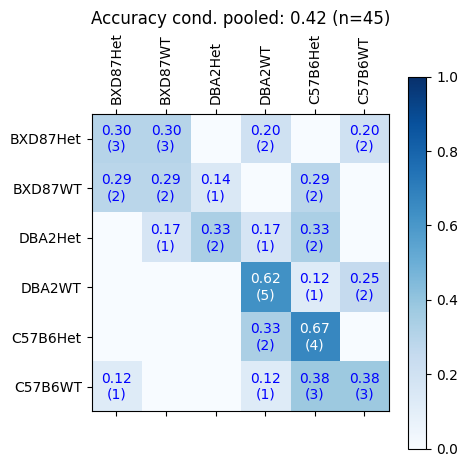

<Figure size 1280x960 with 0 Axes>

<Figure size 1280x960 with 0 Axes>

<Figure size 1280x960 with 0 Axes>

<Figure size 1280x960 with 0 Axes>

In [31]:
for use_spectral in [ False]:
    if use_spectral:
        dict_param_string = 'spectral_'+str(n_windows)+'_'+str(window_length)+'_'+str(n_centroids)
    else:
        dict_param_string = str(n_windows)+'_'+str(window_length)+'_'+str(n_centroids)+'_'+str(centroid_len)+'_'+str_si
         
    all_pred = dict()
    all_pred_maj = dict()
    all_pred_pooled = dict()
    all_labels = dict()
    all_labels_pooled = dict()
    
    task_str = 'type'
    
    for split in range(nsplits):
        for test_fold in range(nfolds):
            segment_param_string = str(n_seg)+'_'+str(split)+str(test_fold)+dict_param_string        
            segment_info_test = pickle.load(open( "data/hpc_segment_info_test_"+segment_param_string+".pickle", "rb" ) )
            count_param_string = str(n_seg)+str(split)+str(test_fold)+dict_param_string
            counts_test = pickle.load(open( "data/hpc_count_test_"+count_param_string+".pickle", "rb" ) )
        
            label_test, subject_test, subject_index2name_test = get_labels_subjects(segment_info_test)        
     
            X_test = np.hstack( [ np.vstack( [counts_test[d,s] for s in segment_info_test ] ) for d in segment_info_test])    
    
            # Load classifier
            filename = 'models/classifiers_l2_'+pool_str+count_param_string+'strain'+ 'LOO' if LOO else ''
            print(filename)
            strain_pipes = pickle.load(open(filename+".pkl", "rb")) 
    
            filename = 'models/classifiers_l2_'+pool_str+count_param_string+'tsc_on_strain'+ 'LOO' if LOO else ''
            print(filename)
            bg_cond_pipes = pickle.load(open(filename+".pkl", "rb")) 
    
            # Prepare prediction 
            y_pred = np.zeros_like(label_test)
            subs_in_test, indices = np.unique(subject_test,return_index=True)
            y_test_pooled = label_test[indices].copy()       # first of each
            y_pred_maj = np.zeros_like(subs_in_test)
            y_pred_pooled = np.zeros_like(subs_in_test)
    
            all_labels[split,test_fold] = label_test.copy()
            all_labels_pooled[split,test_fold] = y_test_pooled.copy()
            
            if LOO:
                n_groups = len(np.unique(subject_test))
            else:
                n_groups = 5
            group_kfold_test = StratifiedGroupKFold(n_splits=n_groups)
            
            for k, (train_index, test_index) in enumerate(group_kfold_test.split(X_test, label_test, subject_test)):        
                X = X_test[test_index]
                y = label_test[test_index]
                groups = subject_test[test_index]
                subs_in_test, indices,inverses = np.unique(groups,return_index=True, return_inverse=True)
            
                strain_pipe_i = strain_pipes[k]
                bg_cond_pipes_i = bg_cond_pipes[k]
                def joined_predict(X):
                    strain_predict = strain_pipe_i.predict(X)
                    conditional_bg_predict = np.vstack([bg_cond_pipes_i[l].predict(X) for l in range(3)])
                    return 2*strain_predict + conditional_bg_predict[strain_predict,np.arange(X.shape[0])].reshape(strain_predict.shape) 
    # oracle case for sanity 
                def joined_predict_oracle(X,true_strain):
                    conditional_bg_predict = np.vstack([bg_cond_pipes_i[l].predict(X) for l in range(3)])
                    return 2*true_strain + conditional_bg_predict[true_strain,np.arange(X.shape[0])].reshape(true_strain.shape) 
                
                def joined_log_proba(X):
                    conditional_bg_log_proba = np.hstack([bg_cond_pipes_i[l].predict_log_proba(X) for l in range(3)])
                    return np.kron(strain_pipe_i.predict_log_proba(X),np.ones((1,2))) + conditional_bg_log_proba
    
                # def joined_log_proba(X):
                #     strain_predict = strain_pipe_i.predict(X)
                #     conditional_bg_log_proba = np.hstack([bg_cond_pipes_i[l].predict_log_proba(X) for l in range(3)])
                #     return 1*(strain_predict[:,np.newaxis]==np.kron(np.arange(3),np.ones((1,2))))  + conditional_bg_log_proba
                    
                
                y_pred[test_index] = joined_predict(X)
    #            y_pred[test_index] = joined_predict_oracle(X,y//2)
    
                test_acc =  np.mean(y==y_pred[test_index]) # each window independently 
                
               # pooling counts per mouse 
                ypooled = y[indices]
                Xpooled = X[indices].copy()
                for l,index in enumerate(indices):
                    Xpooled[l] = np.sum(X[inverses==l],axis=0)
                
                test_acc_pooled =  pipe_i.score(Xpooled,ypooled)
                for sub_i,sub in enumerate(subs_in_test):
    #                y_pred_pooled[sub] = joined_predict_oracle(Xpooled[sub == subs_in_test],ypooled[[sub_i]]//2)[0]
                    y_pred_pooled[sub] = joined_predict(Xpooled[sub == subs_in_test])[0]
            
                for l,index in enumerate(indices):
                    sub = subs_in_test[l]
                    y_pred_maj[sub] = np.argmax(np.sum(joined_log_proba(X[inverses==l]),axis=0))
                
                test_acc_maj =  np.mean(y_pred_maj[subs_in_test]==y_test_pooled[subs_in_test] )
    #            print(f"Fold {k}: C={strain_pipe_i.named_steps['clf'].get_params()['C']:6.3g}"
    #                        +f" Ave.Acc.={test_acc:4.2f} Pool Acc.={test_acc_pooled:4.2f} Maj. Acc.={test_acc_maj:4.2f}")    
            all_pred[split,test_fold] = y_pred.copy()
            all_pred_pooled[split,test_fold] = y_pred_pooled.copy()
            all_pred_maj[split,test_fold] = y_pred_maj.copy()
    
    micro_acc_2 = np.zeros((nsplits))
    for split in range(nsplits):
        y_test = np.concatenate([all_labels[split,test_fold] for test_fold in range(nfolds) ])
        y_pred = np.concatenate([all_pred[split,test_fold] for test_fold in range(nfolds) ])
        y_test_pooled = np.concatenate([all_labels_pooled[split,test_fold] for test_fold in range(nfolds) ])
        y_pred_pooled = np.concatenate([all_pred_pooled[split,test_fold] for test_fold in range(nfolds) ])
        y_pred_maj = np.concatenate([all_pred_maj[split,test_fold] for test_fold in range(nfolds) ])
        run_name = str(n_seg)+pool_str+str(split)+dict_param_string
        micro_acc_2[split]=np.mean(y_pred_pooled==y_test_pooled)
        plot_confusion_matrix(y_test_pooled,y_pred_pooled,types,"cond. pooled",'cond'+task_str+run_name+"_pooled")
        if split>0:
            plt.close()
           
    print(micro_acc_2,np.mean(micro_acc_2),np.std(micro_acc_2,ddof=1),np.mean(micro_acc_2)+np.array([-1,1])*np.std(micro_acc_2,ddof=1)*np.sqrt((1/nsplits+n/(n-1)))*stats.t.ppf(0.975, nsplits - 1))
    
